# Weekly project part 1
Using the image "appletree.jpg"
1) Can you segment the apples from the tree?
2) Can you get the computer to count how many there are? 
    How close can you get to the ground truth? (there are 26 apples in the image)
3) Can you change the color of one of them?
4) Can you segment the leaves?
    
    
# Weekly project part 2
1) Remove the greenscreen and replace the background in "itssp.png".
2) Can you improve the edge with eroding/dilating?


In [3]:
import cv2
import numpy as np
import imutils
from matplotlib import pyplot as plt

In [4]:
path = "appletree.jpg"

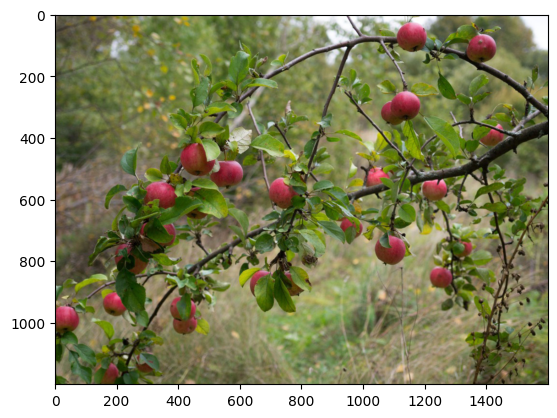

In [5]:
bgr_img = cv2.imread(path)
b,g,r = cv2.split(bgr_img)       # get b,g,r
image = cv2.merge([r,g,b])
plt.imshow(image)

22


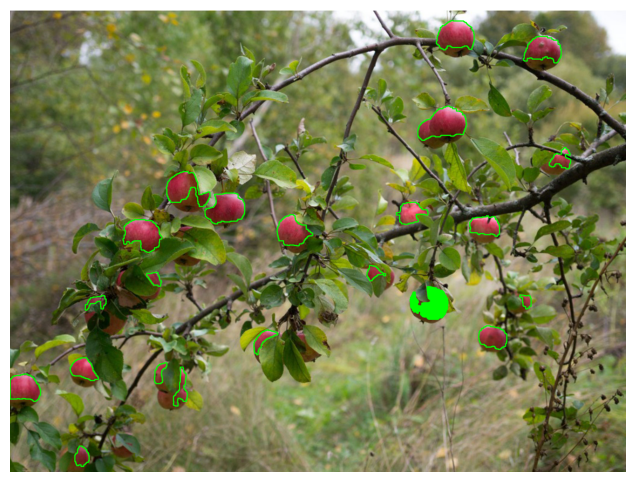

In [159]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load and preprocess
bgr_img = cv2.imread(path)
hsv = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2HSV)

# Red ranges
lower_red1 = np.array([0, 70, 30])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([160, 0, 0])
upper_red2 = np.array([190, 255, 255])

mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
mask = cv2.bitwise_or(mask1, mask2)

# Morphological cleanup
kernel = np.ones((5, 5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# Find contours
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Copy original image for drawing
output = bgr_img.copy()

# Area threshold
min_area = 400  

i=0
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area >= min_area:
        i += 1
        # Draw green boundary (thickness=2)
        cv2.drawContours(output, [cnt], -1, (0, 255, 0), 2)

print(i)
j = 0
indx = 8
# Draw filled green contours (thickness=-1 fills the contour)
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area >= min_area:
        if indx < j <= indx+1:
            cv2.drawContours(output, [cnt], -1, (0, 255, 0), thickness=-1)
        j += 1
# Show results
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

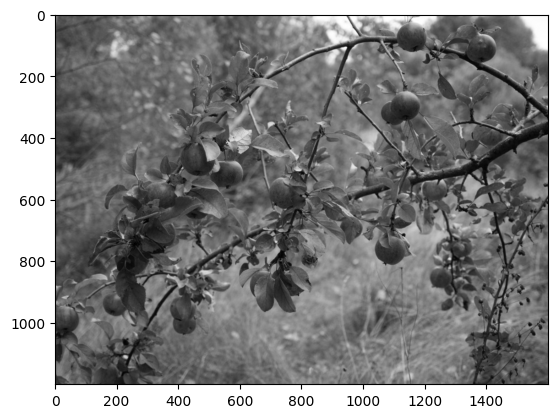

In [160]:
image = bgr_img.copy()

gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
plt.imshow(gray, cmap = 'gray')

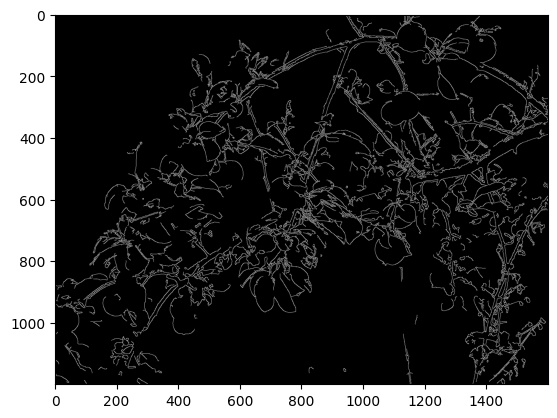

In [161]:
edged = cv2.Canny(gray, 70, 200)
plt.imshow(edged, cmap='gray')

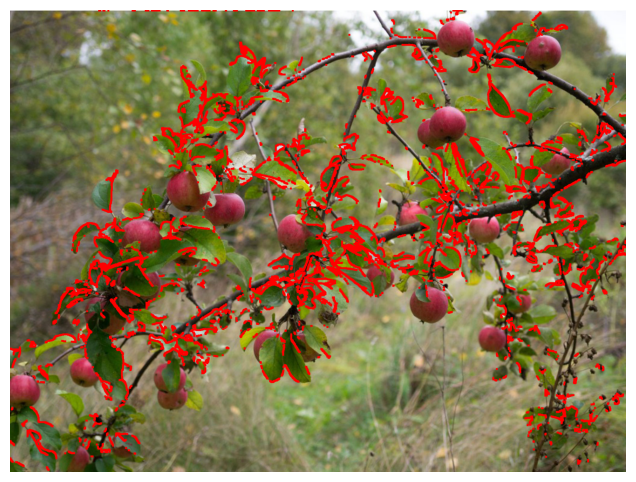

In [162]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
bgr_img = cv2.imread(path)

# Convert to HSV for color segmentation
hsv = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2HSV)

# Looser green range in HSV
lower_green = np.array([35, 30, 30])
upper_green = np.array([85, 255, 255])
green_mask = cv2.inRange(hsv, lower_green, upper_green)

# Convert image to grayscale for edge detection
gray = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)
edged = cv2.Canny(gray, 70, 220)

# Combine edges and green mask
segmented = cv2.bitwise_and(green_mask, edged)

# Dilate edges to make them thicker
kernel = np.ones((3,3), np.uint8)  # 3x3 square kernel
segmented_dilated = cv2.dilate(segmented, kernel, iterations=2)  # increase iterations for thicker lines

# Create an overlay: copy original image
overlay = bgr_img.copy()

# Color the dilated edges red
overlay[segmented_dilated > 0] = [0, 0, 255]  # BGR red

# Show overlay
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()